# Adidas Sales Profitability & Commercial Finance Analysis


**Dataset:** Adidas US Sales Dataset (2020–2021)  |  **Tools:** Python · Pandas · Matplotlib · Seaborn 

---

## Introduction

This project analyses Adidas US retail sales data from a commercial finance and FP&A perspective. Rather than treating this as a purely descriptive exercise, the analysis is built around the questions a finance team would ask ahead of a quarterly business review: **who is driving revenue and profit, where are the margin opportunities, and what should the business prioritise?**

The dataset covers two fiscal years, 2020 and 2021 and spans six retail partners, five US regions, six product categories, and three sales channels. The analysis moves from high-level KPIs down to granular city- and product-level profitability, mirroring the structure of a commercial finance review deck.

## Business Objective

This analysis is designed to answer four core commercial finance questions:

1. **What are the key profitability drivers?** Identify which retailers, products, regions, and channels most directly influence operating profit and margin performance.
2. **Who performs best commercially?** Determine which accounts and categories generate the strongest financial returns — not just the highest revenue.
3. **Does high revenue mean high profit?** Assess whether volume translates into margin, and flag where revenue rankings diverge from profit rankings.
4. **What should Adidas prioritise?** Provide finance-backed recommendations for account management, product portfolio decisions, and regional investment.

The output reflects the type of analysis a commercial finance analyst or FP&A business partner would produce to support strategic planning and quarterly business reviews.

## Dataset Overview

The dataset contains transaction-level Adidas US sales records across 2020 and 2021. Each row represents an individual sales entry with the following fields:

| Column | Description |
|--------|-------------|
| `retailer` | Retail partner through which the sale was made (e.g. West Gear, Foot Locker) |
| `invoice_date` | Date of the transaction — used to build monthly and annual trends |
| `region` | US geographic region (West, Northeast, South, Southeast, Midwest) |
| `state` | US state of the transaction |
| `city` | City-level granularity for localised profitability analysis |
| `product` | Product category (e.g. Men’s Street Footwear, Women’s Apparel) |
| `price_per_unit` | Selling price per unit — tracks average selling price (ASP) |
| `units_sold` | Volume of units transacted |
| `total_sales` | Gross revenue for the transaction |
| `operating_profit` | Profit after operating costs — the primary profitability KPI |
| `operating_margin` | Operating profit as a share of total sales — the efficiency metric |
| `sales_method` | Channel through which the sale occurred (In-store, Outlet, Online) |

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')
os.makedirs('visuals', exist_ok=True)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['figure.dpi'] = 100

print('Libraries loaded successfully.')

In [ ]:
df = pd.read_excel('Adidas US Sales Datasets.xlsx', skiprows=4)

# Drop fully empty rows and columns
df.dropna(how='all', inplace=True)
df.dropna(axis=1, how='all', inplace=True)

# Clean column names to snake_case
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('/', '_')
    .str.replace('(', '', regex=False)
    .str.replace(')', '', regex=False)
)

# Convert invoice_date to datetime
df['invoice_date'] = pd.to_datetime(df['invoice_date'])

# Convert numeric columns
for col in ['price_per_unit', 'units_sold', 'total_sales', 'operating_profit', 'operating_margin']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Remove duplicates and reset index
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

# Add time-based helper columns
df['year']  = df['invoice_date'].dt.year
df['month'] = df['invoice_date'].dt.to_period('M').astype(str)

print(f'Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')

In [ ]:
print('=== COLUMN NAMES ===')
print(df.columns.tolist())

print('\n=== MISSING VALUES ===')
print(df.isnull().sum())

print('\n=== DUPLICATES ===')
print(f'Duplicate rows: {df.duplicated().sum()}')

print('\n=== SAMPLE DATA ===')
df.head()

In [ ]:
df.describe().T.round(2)

### Data Quality Note

The dataset is clean with no missing values or duplicate records after initial processing. All numeric columns have been successfully cast to the correct data types, and the invoice date field has been converted to datetime. The dataset is ready for analysis.

In [ ]:
total_sales     = df['total_sales'].sum()
total_profit    = df['operating_profit'].sum()
avg_margin      = df['operating_margin'].mean()
total_units     = df['units_sold'].sum()
avg_price       = df['price_per_unit'].mean()
profit_per_unit = total_profit / total_units

kpi_df = pd.DataFrame({
    'KPI': [
        'Total Revenue',
        'Total Operating Profit',
        'Average Operating Margin',
        'Total Units Sold',
        'Average Selling Price',
        'Profit per Unit',
    ],
    'Value': [
        f'${total_sales:,.0f}',
        f'${total_profit:,.0f}',
        f'{avg_margin:.1%}',
        f'{total_units:,.0f}',
        f'${avg_price:.2f}',
        f'${profit_per_unit:.2f}',
    ]
})

print('\n' + '='*45)
print('    KEY PERFORMANCE INDICATORS')
print('='*45)
print(kpi_df.to_string(index=False))
print('='*45)

## KPI Summary — Finance Interpretation

The KPI table above sets the commercial baseline for the entire analysis. A few points worth contextualising:

- **Total Revenue** represents the aggregate gross sales value across all retailers, regions, products, and channels over the two-year period. It tells us the commercial scale of the Adidas US business and is the top-line figure a finance team would track against annual budget.

- **Total Operating Profit** is what remains after operating costs are deducted from revenue. This is the primary profitability KPI — it reflects how much of the revenue the business actually retains. Revenue without profit context tells an incomplete story.

- **Average Operating Margin** measures how efficiently sales convert into profit. A margin in the mid-to-high thirties is healthy for a consumer goods and retail business, suggesting Adidas maintains strong pricing power and a well-managed cost structure across its US portfolio.

- **Profit per Unit** normalises profitability at the transaction level, removing the volume effect. It is particularly useful when comparing across retailers or regions where unit volumes differ significantly — a high profit per unit means the business extracts more value per sale, which matters when volumes plateau or mix shifts.

Together, these KPIs frame the 'what' of commercial performance. The retailer, product, regional, and channel analyses that follow break down the 'where' and 'why'.

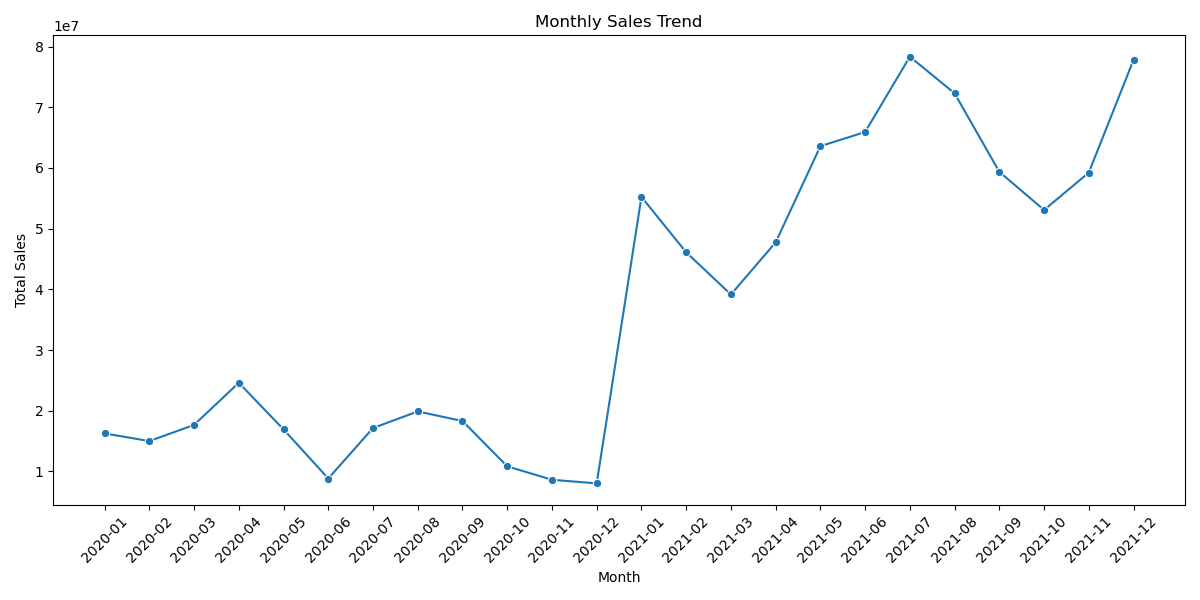

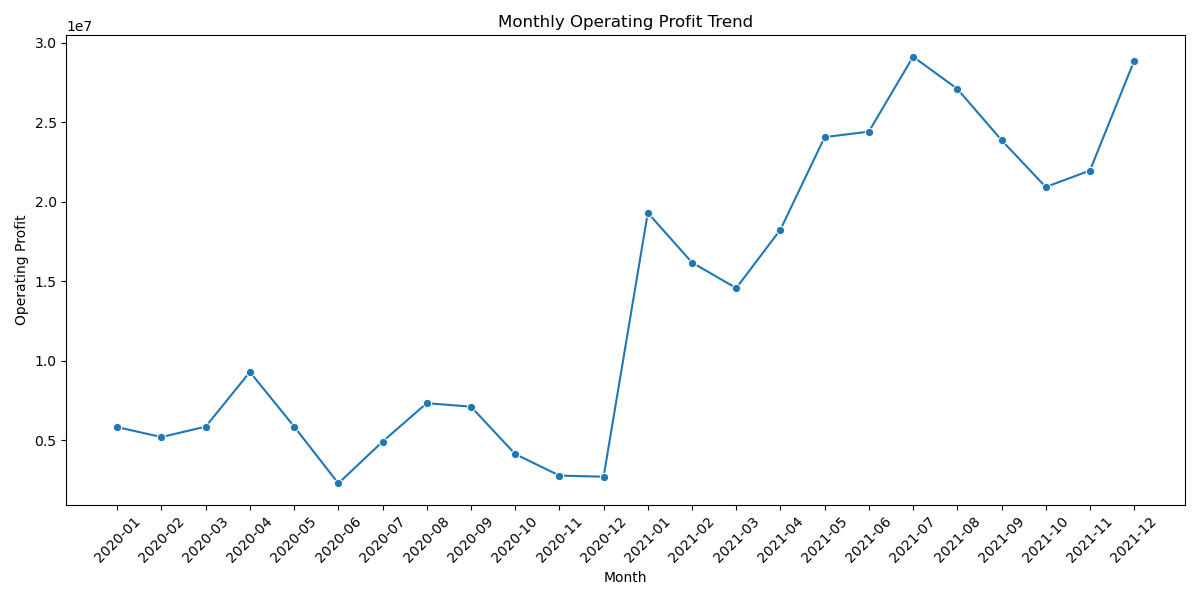

In [ ]:
monthly = (
    df.groupby('month')
    .agg(total_sales=('total_sales', 'sum'),
         operating_profit=('operating_profit', 'sum'))
    .reset_index()
    .sort_values('month')
)
monthly['sales_growth_pct']  = monthly['total_sales'].pct_change() * 100
monthly['profit_growth_pct'] = monthly['operating_profit'].pct_change() * 100

print('Monthly Sales & Profit Summary:')
print(monthly[['month','total_sales','operating_profit',
               'sales_growth_pct','profit_growth_pct']].to_string(index=False))

# Monthly Sales Trend
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly['month'], monthly['total_sales'], marker='o', linewidth=2, color='steelblue')
ax.set_title('Monthly Sales Trend')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('visuals/monthly_sales_trend.png', dpi=100, bbox_inches='tight')
plt.show()

# Monthly Operating Profit Trend
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly['month'], monthly['operating_profit'], marker='o', linewidth=2, color='steelblue')
ax.set_title('Monthly Operating Profit Trend')
ax.set_xlabel('Month')
ax.set_ylabel('Operating Profit')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('visuals/monthly_profit_trend.png', dpi=100, bbox_inches='tight')
plt.show()

## Monthly Sales & Profit Trend — Finance Interpretation

The monthly trend charts reveal one of the most commercially significant stories in this dataset.

**2020 performance was severely compressed.** Monthly revenue across 2020 ranged from roughly $8M to $25M, with no month exceeding $25M. This is consistent with the retail and consumer spending disruption caused by COVID-19. Any year-on-year growth calculations drawn from this dataset will show large percentage increases simply because the 2020 base is so low — this context is essential for accurate FP&A work. The numbers are not wrong; the baseline is just distorted.

**The jump into January 2021 is structural, not seasonal.** The business does not gradually recover — it steps up to roughly 5–6x the December 2020 monthly revenue almost immediately and never returns to 2020 levels. This suggests a combination of pent-up consumer demand, retailer restocking cycles, and improved supply chain conditions converging at the same time.

**Within 2021, clear seasonality emerges.** Two peaks are visible: July 2021 and December 2021, both reaching approximately $78M in monthly revenue. These align with mid-year summer selling (back-to-school, summer sport) and end-of-year holiday gifting — patterns that are consistent with Adidas’ product categories. For production planning and inventory management, these peaks should be built into the demand forecast well in advance.

**Profit mirrors sales with near-identical shape.** The operating profit trend line tracks revenue closely throughout the entire period, suggesting margins are relatively stable month to month. This is commercially positive: the business is not sacrificing margin to sustain sales volumes in slower months. For FP&A budgeting purposes, a profit model that scales proportionally with revenue simplifies forward planning and scenario analysis.

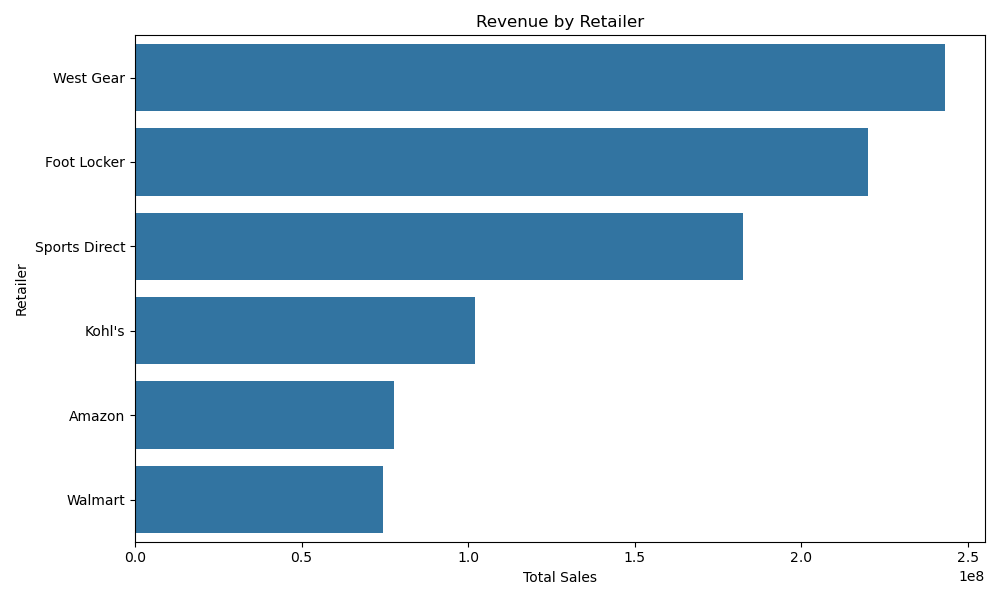

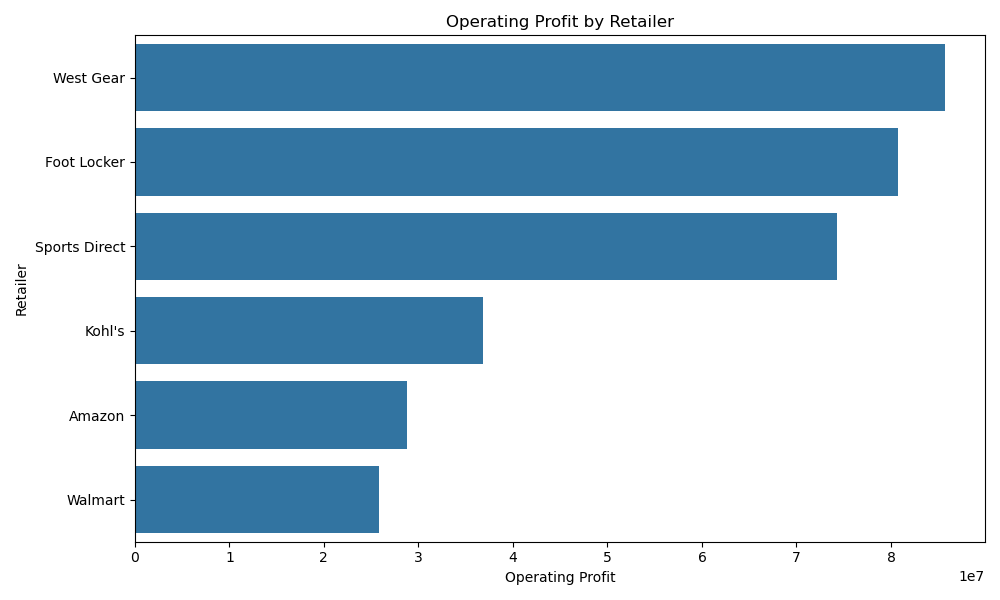

In [ ]:
retailer_summary = (
    df.groupby('retailer')
    .agg(
        total_sales=('total_sales', 'sum'),
        operating_profit=('operating_profit', 'sum'),
        avg_margin=('operating_margin', 'mean')
    )
    .reset_index()
    .sort_values('total_sales', ascending=False)
)
retailer_summary['avg_margin_pct'] = (retailer_summary['avg_margin'] * 100).round(1)

print('Retailer Performance Summary:')
print(retailer_summary[['retailer','total_sales','operating_profit','avg_margin_pct']].to_string(index=False))

# Revenue by Retailer
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=retailer_summary.sort_values('total_sales'),
            x='total_sales', y='retailer', ax=ax, color='steelblue')
ax.set_title('Revenue by Retailer')
ax.set_xlabel('Total Sales')
ax.set_ylabel('Retailer')
plt.tight_layout()
plt.savefig('visuals/revenue_by_retailer.png', dpi=100, bbox_inches='tight')
plt.show()

# Operating Profit by Retailer
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=retailer_summary.sort_values('operating_profit'),
            x='operating_profit', y='retailer', ax=ax, color='steelblue')
ax.set_title('Operating Profit by Retailer')
ax.set_xlabel('Operating Profit')
ax.set_ylabel('Retailer')
plt.tight_layout()
plt.savefig('visuals/profit_by_retailer.png', dpi=100, bbox_inches='tight')
plt.show()

## Retailer Performance — Finance Interpretation

The retailer analysis provides a clear commercial ranking of Adidas’ six US retail partners and surfaces a number of insights worth discussing in any key account review.

**West Gear leads across all commercial dimensions.** With approximately $245M in revenue and $85M in operating profit, West Gear is the strongest retail account in the portfolio. Foot Locker follows closely in second place on both metrics, and Sports Direct third. These three accounts collectively account for roughly 71% of total revenue, which means Adidas’ commercial performance in the US is highly concentrated in its top-tier partners.

**The revenue and profit rankings are perfectly aligned.** This is a notable finding: there is no high-revenue, low-margin retailer in the mix — the accounts generating the most sales are also generating the most profit. From a commercial finance perspective, this is a clean picture. It tells us that Adidas is not buying revenue through unsustainable margin concessions at its largest accounts.

**The gap to the lower tier is significant.** Kohl’s, Amazon, and Walmart each contribute substantially less in both revenue and profit. Amazon and Walmart sit at the bottom on both metrics, which raises a legitimate question for commercial finance: do these accounts generate adequate returns relative to the investment required to service them? Pricing pressure, fulfilment costs, and promotional requirements in mass-market and online retail channels can quietly erode what looks like reasonable top-line revenue.

**Key account management implication:** protect and deepen the West Gear, Foot Locker, and Sports Direct relationships. Quantify the true margin contribution of Kohl’s, Amazon, and Walmart before committing additional trade investment to those channels.

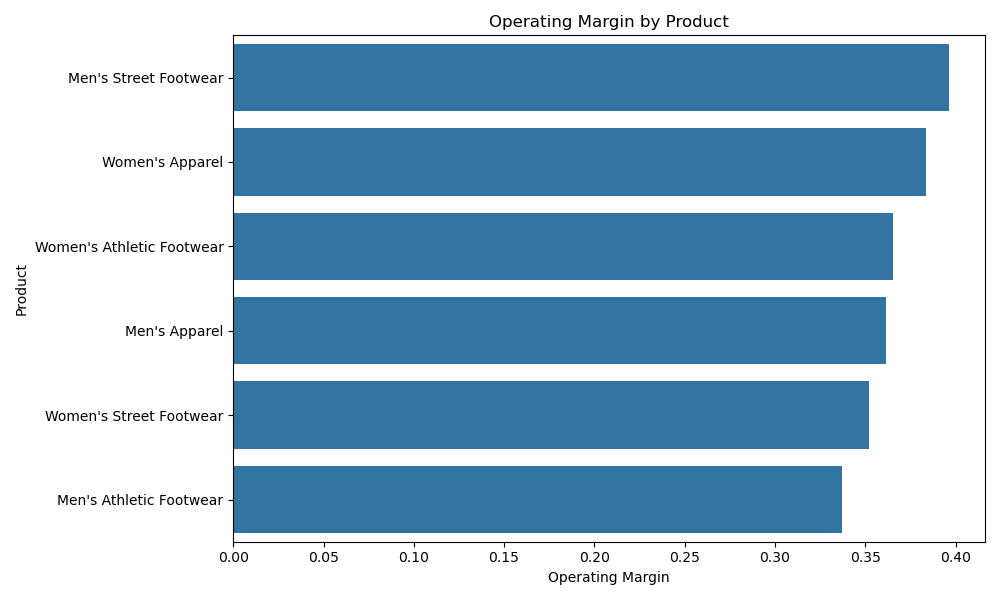

In [ ]:
product_summary = (
    df.groupby('product')
    .agg(
        total_sales=('total_sales', 'sum'),
        operating_profit=('operating_profit', 'sum'),
        avg_margin=('operating_margin', 'mean')
    )
    .reset_index()
    .sort_values('avg_margin', ascending=False)
)

print('Product Performance Summary:')
print(product_summary.to_string(index=False))

# Operating Margin by Product
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=product_summary.sort_values('avg_margin'),
            x='avg_margin', y='product', ax=ax, color='steelblue')
ax.set_title('Operating Margin by Product')
ax.set_xlabel('Operating Margin')
ax.set_ylabel('Product')
plt.tight_layout()
plt.savefig('visuals/margin_by_product.png', dpi=100, bbox_inches='tight')
plt.show()

## Product Profitability — Finance Interpretation

The product margin chart gives us the portfolio efficiency view — which categories are contributing the most margin per dollar of revenue, independent of volume.

**Men’s Street Footwear commands the highest average operating margin at approximately 40%.** This is the strongest product in the portfolio from a commercial returns perspective. Women’s Apparel sits second at around 38%, followed by Women’s Athletic Footwear at 37%.

**Men’s Athletic Footwear is the margin laggard at approximately 34%.** While still comfortably profitable, it sits roughly 6 percentage points below the portfolio leader. That gap is commercially meaningful at scale: across millions of dollars in revenue, a 6-point margin differential translates into a significant difference in absolute profit contribution. The root cause could be higher input costs, more aggressive retail pricing in a competitive athletic footwear market, or a SKU mix skewed toward lower-priced entry-level products.

**The overall margin range is narrow — approximately 34% to 40%.** This tells us Adidas maintains reasonable pricing consistency across its product portfolio, without any category acting as a structural drag. From a portfolio health standpoint, that is a positive signal.

**Product strategy implications:** defend and grow high-margin categories (Men’s Street Footwear, Women’s Apparel). For Men’s Athletic Footwear, the question is whether the margin gap reflects a structural market constraint or a fixable issue around product mix, cost management, or pricing architecture. Even a 2–3 point improvement at scale would deliver a material lift to group profit.

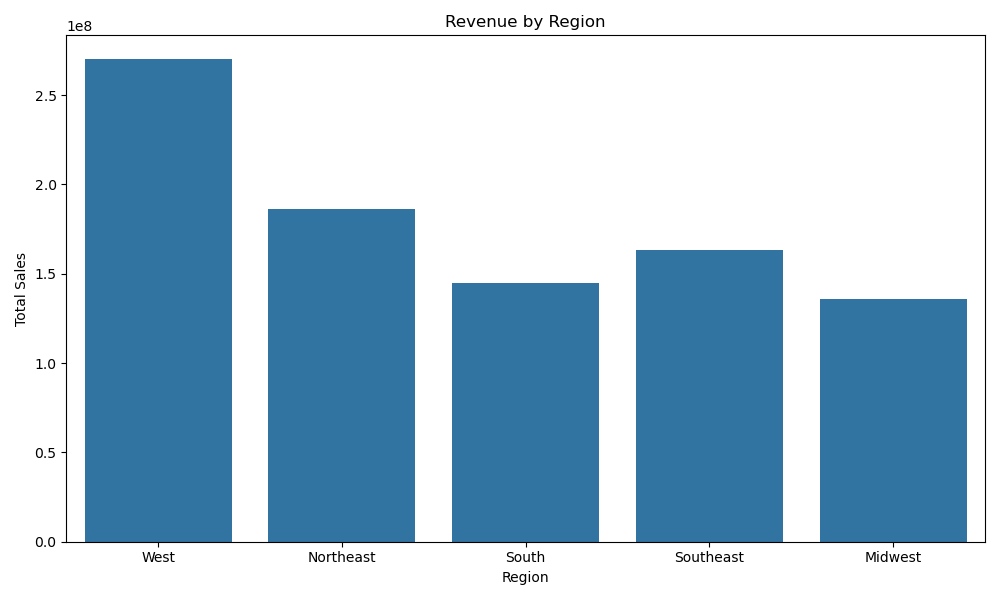

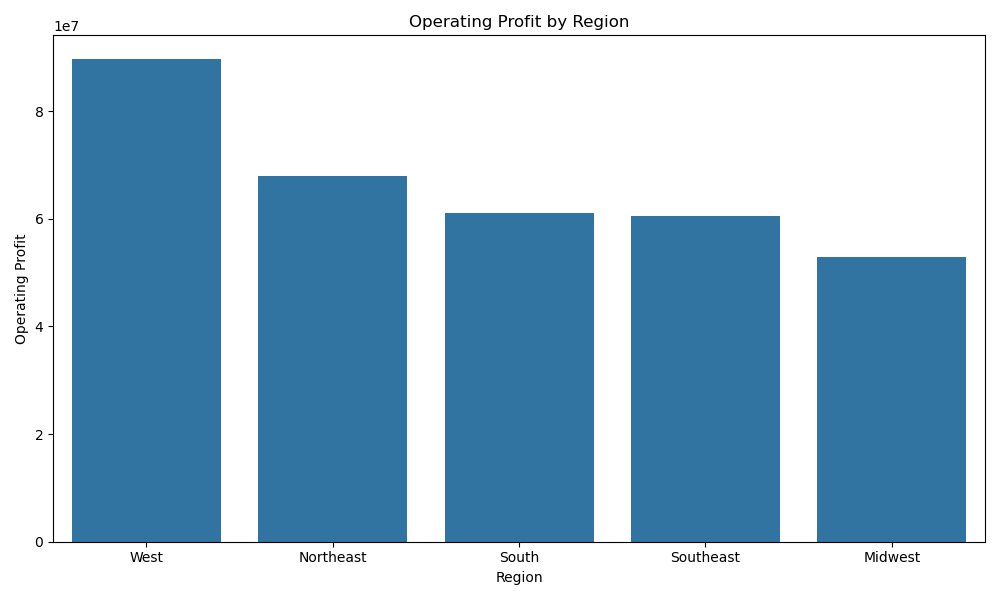

In [ ]:
region_summary = (
    df.groupby('region')
    .agg(
        total_sales=('total_sales', 'sum'),
        operating_profit=('operating_profit', 'sum'),
        avg_margin=('operating_margin', 'mean')
    )
    .reset_index()
    .sort_values('total_sales', ascending=False)
)

print('Regional Performance Summary:')
print(region_summary.to_string(index=False))

# Revenue by Region
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=region_summary, x='region', y='total_sales',
            order=region_summary['region'], ax=ax, color='steelblue')
ax.set_title('Revenue by Region')
ax.set_xlabel('Region')
ax.set_ylabel('Total Sales')
plt.tight_layout()
plt.savefig('visuals/revenue_by_region.png', dpi=100, bbox_inches='tight')
plt.show()

# Operating Profit by Region
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=region_summary, x='region', y='operating_profit',
            order=region_summary['region'], ax=ax, color='steelblue')
ax.set_title('Operating Profit by Region')
ax.set_xlabel('Region')
ax.set_ylabel('Operating Profit')
plt.tight_layout()
plt.savefig('visuals/profit_by_region.png', dpi=100, bbox_inches='tight')
plt.show()

## Regional Performance — Finance Interpretation

The regional breakdown shows where Adidas’ US commercial engine is most powerful — and where the growth opportunity is being left on the table.

**The West is the outright commercial leader.** With approximately $270M in revenue and $90M in operating profit, the West accounts for the largest share of national performance. This is commercially intuitive given the West’s population density, consumer spending levels, and concentration of fitness and lifestyle culture in major markets like Los Angeles and San Francisco.

**The Northeast is a strong second.** At roughly $185M in revenue and $67M in profit, the Northeast — anchored by New York City — is a critical market. New York emerges as the single highest-profit city in the separate city analysis, which reinforces the Northeast’s importance to the national total.

**A subtle but important margin dynamic emerges between the South and Southeast.** The South generates lower absolute revenue than the Southeast (~$145M vs ~$163M), yet its operating profit is comparable (~$61M vs ~$60M). This implies the South operates at a higher effective margin — a finding that is confirmed and amplified in the heatmap analysis, where the South produces the strongest region-product margin combinations in the entire dataset.

**The Midwest is the weakest region on both metrics** — lowest revenue (~$133M) and lowest profit (~$53M). From a resource allocation perspective, this raises a strategic question: is the Midwest underperforming due to insufficient investment, or because market conditions are structurally less favourable for Adidas’ product mix? The answer determines whether the response should be growth investment or portfolio rationalisation.

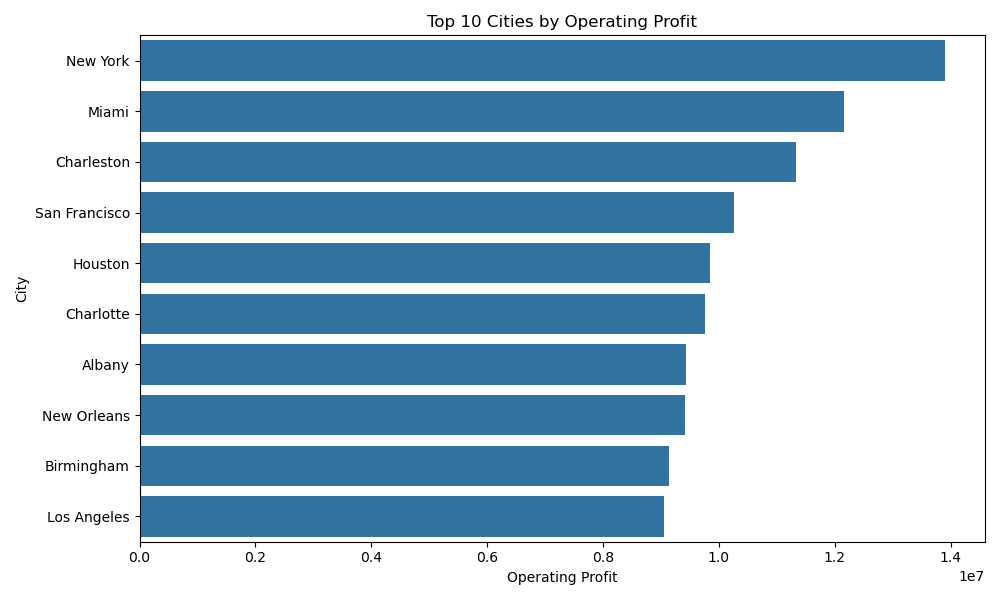

In [ ]:
city_summary = (
    df.groupby('city')
    .agg(
        total_sales=('total_sales', 'sum'),
        operating_profit=('operating_profit', 'sum')
    )
    .reset_index()
    .sort_values('operating_profit', ascending=False)
    .head(10)
)

print('Top 10 Cities by Operating Profit:')
print(city_summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=city_summary.sort_values('operating_profit'),
            x='operating_profit', y='city', ax=ax, color='steelblue')
ax.set_title('Top 10 Cities by Operating Profit')
ax.set_xlabel('Operating Profit')
ax.set_ylabel('City')
plt.tight_layout()
plt.savefig('visuals/top_10_cities_profit.png', dpi=100, bbox_inches='tight')
plt.show()

## Top 10 Cities by Profit — Finance Interpretation

City-level profitability analysis is a high-value tool for commercial finance teams because it moves beyond broad regional aggregates to pinpoint where specific investment decisions should be made — distribution, marketing, retailer support, and inventory positioning.

**New York City is the single most profitable market**, generating approximately $14M in operating profit — roughly $2M more than the second-ranked city, Miami. For any commercial decision involving geographic prioritisation — exclusive product launches, targeted trade investment, or in-store experience upgrades — New York should sit at the top of the list.

**Miami at second and Charleston at third are noteworthy.** Miami’s performance is consistent with its status as a major population and tourism hub with strong consumer spending. Charleston’s appearance at number three is more surprising given its relatively smaller population base — it suggests either a highly effective retailer network, a consumer profile that aligns well with Adidas’ product range, or a favourable product mix that skews toward higher-margin categories.

**The mid-tier cluster is tightly grouped.** Houston, Charlotte, Albany, New Orleans, Birmingham, and Los Angeles all fall between approximately $9M and $10.5M. The fact that Los Angeles — one of the largest US cities by population — ranks tenth behind smaller cities like Albany and Charleston suggests there may be untapped potential in LA, or that competitive intensity in that market is suppressing Adidas’ share of wallet.

**Practical application:** city-level data like this can inform a tiered investment framework — directing marketing spend, distribution investment, and field sales support proportionally toward markets with demonstrated returns, rather than spreading resources uniformly across the country.

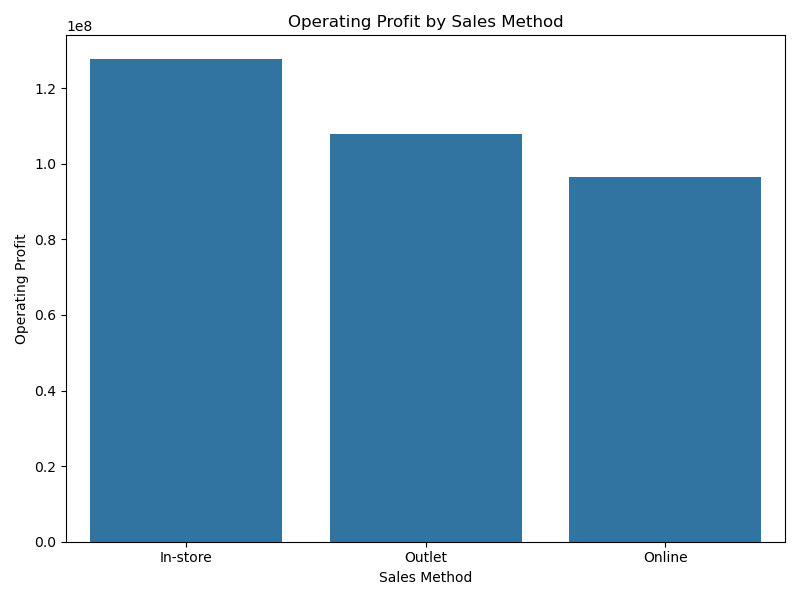

In [ ]:
method_summary = (
    df.groupby('sales_method')
    .agg(
        total_sales=('total_sales', 'sum'),
        operating_profit=('operating_profit', 'sum'),
        avg_margin=('operating_margin', 'mean')
    )
    .reset_index()
    .sort_values('operating_profit', ascending=False)
)

print('Sales Method Performance Summary:')
print(method_summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=method_summary, x='sales_method', y='operating_profit',
            order=method_summary['sales_method'], ax=ax, color='steelblue')
ax.set_title('Operating Profit by Sales Method')
ax.set_xlabel('Sales Method')
ax.set_ylabel('Operating Profit')
plt.tight_layout()
plt.savefig('visuals/sales_method_profit.png', dpi=100, bbox_inches='tight')
plt.show()

## Sales Method Analysis — Finance Interpretation

The channel analysis compares three sales methods — In-store, Outlet, and Online — and the results carry important implications for how Adidas manages its channel mix strategy.

**In-store is the most profitable channel**, generating approximately $127M in operating profit — roughly 32% more than Online ($96M) and 18% more than Outlet ($108M). In-store retail typically benefits from full-price selling, higher average transaction values, and the ability to upsell and cross-sell adjacent products. These dynamics naturally support stronger margin outcomes compared to channels that rely more heavily on discounting or promotional pricing.

**Outlet channels outperform Online on absolute profit, which warrants scrutiny.** Outlet typically moves clearance or end-of-line inventory at discounted prices — so its outperformance of Online in absolute profit terms suggests either that Outlet handles very large volumes, or that Online’s cost structure (fulfilment, returns, digital marketing) is more expensive than it appears at the gross revenue level.

**Online being the smallest contributor does not mean it should be deprioritised.** Online retail is structurally the fastest-growing channel across consumer categories, and its current position at the bottom may simply reflect the maturity of Adidas’ e-commerce business in this period. The more important question for FP&A is whether Online is growing its share of revenue and profit year over year — and whether its margin rate is improving as scale increases and fulfilment costs are spread more broadly.

**Channel mix is a long-term profitability lever.** As the portfolio shifts from In-store to Online over time, understanding whether that shift is margin-accretive or dilutive is critical for building reliable long-range financial models.

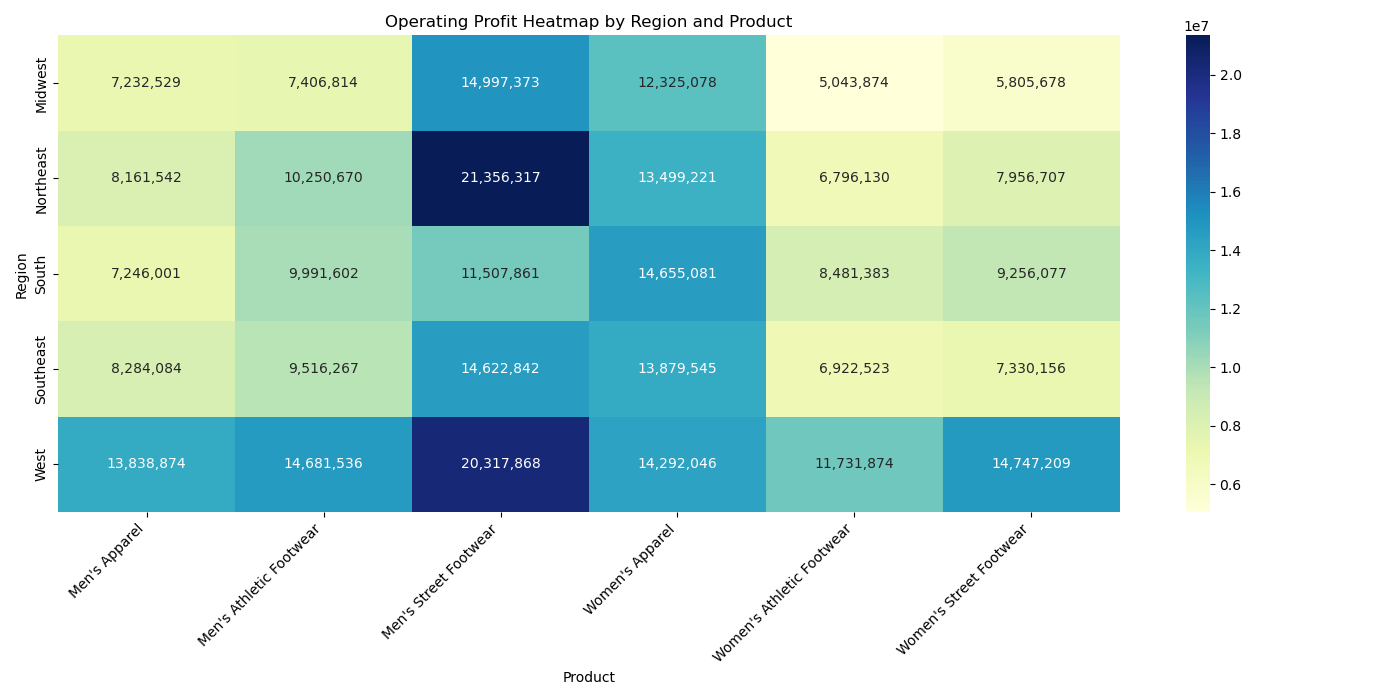

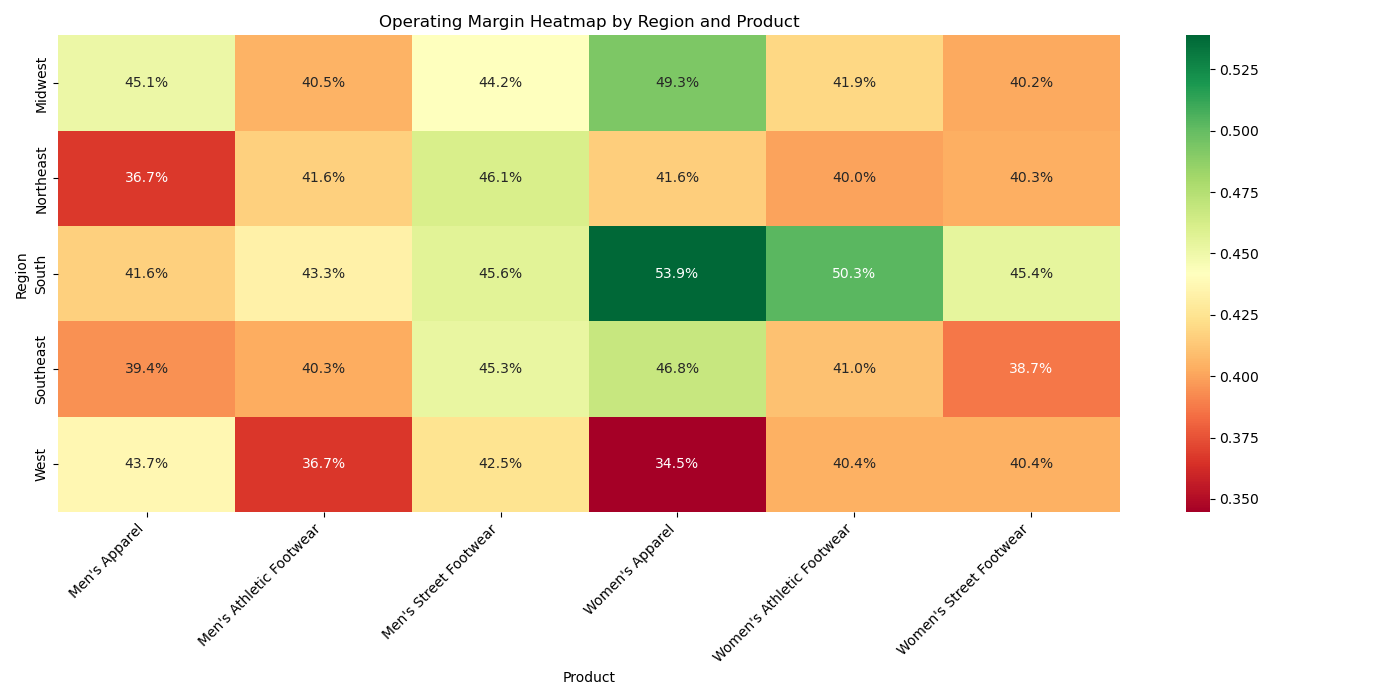

In [ ]:
heat_df = (
    df.groupby(['region', 'product'])
    .agg(total_sales=('total_sales', 'sum'),
         operating_profit=('operating_profit', 'sum'))
    .reset_index()
)
heat_df['margin_pct'] = (heat_df['operating_profit'] / heat_df['total_sales']) * 100

# Operating Profit heatmap (absolute values)
profit_pivot = heat_df.pivot(index='region', columns='product', values='operating_profit')

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(profit_pivot, annot=True, fmt='.0f', cmap='YlGnBu', linewidths=0.5, ax=ax)
ax.set_title('Operating Profit Heatmap by Region and Product')
ax.set_xlabel('Product')
ax.set_ylabel('Region')
plt.tight_layout()
plt.savefig('visuals/profit_heatmap_region_product.png', dpi=100, bbox_inches='tight')
plt.show()

# Operating Margin heatmap (percentage)
margin_pivot = heat_df.pivot(index='region', columns='product', values='margin_pct')
annot_data   = margin_pivot.applymap(lambda x: f'{x:.1f}%')

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(margin_pivot, annot=annot_data, fmt='', cmap='RdYlGn', linewidths=0.5, ax=ax)
ax.set_title('Operating Margin Heatmap by Region and Product')
ax.set_xlabel('Product')
ax.set_ylabel('Region')
plt.tight_layout()
plt.savefig('visuals/margin_heatmap_region_product.png', dpi=100, bbox_inches='tight')
plt.show()

## Operating Margin Heatmap (Region × Product) — Finance Interpretation

The heatmaps above bring together two analytical dimensions simultaneously — region and product — to reveal which combinations deliver the strongest and weakest commercial outcomes. This is the kind of cross-dimensional analysis that finance teams use when making trade investment decisions, range planning choices, or regional go-to-market allocations.

**How to read the margin heatmap:** Each cell shows the operating margin for a specific region-product pairing, calculated as operating profit divided by total sales for that combination. Darker green indicates stronger margins; darker red indicates weaker ones. The profit heatmap above it shows the equivalent absolute dollar figures.

**The standout combination is South + Women’s Apparel at 53.9%.** This is materially above the portfolio average and the highest single cell in the matrix. It tells us that in the South region, Women’s Apparel generates exceptional margin efficiency — far above what Women’s Apparel achieves in any other region. Whether this is driven by retail partner mix, consumer pricing dynamics, or a favourable product assortment, this combination represents a disproportionate profit opportunity that should be actively scaled.

**South + Women’s Athletic Footwear at 50.3% is equally compelling.** The South region consistently outperforms on women’s categories across the board, which is a clear signal for range and trade investment prioritisation in that geography.

**The West’s weaker margin cells are commercially important.** Given that the West is the highest-revenue region, low margins in specific combinations carry significant financial weight. West + Women’s Apparel at 34.5% is the lowest cell in the entire matrix — a stark contrast to the South’s 53.9% for the same product. West + Men’s Athletic Footwear at 36.7% is also below average. These combinations are not loss-making, but the margin gap versus their potential is large enough to merit investigation.

**Midwest + Women’s Apparel at 49.3% is an underappreciated bright spot.** Despite the Midwest being the lowest-performing region in absolute terms, Women’s Apparel there generates near-premium margins — which suggests the issue is volume and market penetration, not margin efficiency. This is a meaningful distinction for resource allocation decisions: if the Midwest can grow volume in Women’s Apparel while maintaining those margins, the profit uplift could be substantial.

## Key Insights

1. **The 2020–2021 growth story is driven by recovery, not organic momentum.** Monthly revenue in 2021 ran at 4–5x the 2020 level due to COVID-19 base effects. Year-on-year comparisons must be framed with that context to avoid misrepresenting underlying commercial performance.

2. **West Gear and Foot Locker are the commercial anchors of the US portfolio.** These two retailers alone account for a disproportionate share of total revenue and profit. Any disruption to these relationships — terms renegotiation, distribution pullback, competitive displacement — would have a material impact on the national P&L.

3. **Revenue and profit rankings are aligned across retailers — no account is commercially dilutive at the top end.** The absence of a high-revenue, low-margin retailer in the top three is a healthy commercial signal. The lower-tier accounts (Amazon, Walmart) are where margin scrutiny is most warranted.

4. **Men’s Street Footwear is the strongest product margin; Men’s Athletic Footwear is the weakest.** The 6-point differential between the portfolio’s best and worst product margins is commercially significant at scale and warrants a pricing or cost structure review.

5. **The South region punches above its weight on margins despite ranking fourth on revenue.** South + Women’s Apparel at 53.9% margin is the highest region-product combination in the dataset, and South + Women’s Athletic Footwear at 50.3% is second. The South is a high-quality profit contributor even if its volume lags the West and Northeast.

6. **In-store remains the most profitable channel, but the Online trajectory matters more for long-term planning.** The current channel profit split reflects the historical maturity of each channel. As e-commerce grows, understanding its margin dynamics will become increasingly critical for FP&A forecasting.

7. **New York City stands out as the single most profitable local market**, with a clear gap over Miami in second place. Commercially, this concentration of profit in a handful of cities means geographic investment strategy should be data-led, not uniformly distributed.

## Commercial Finance Recommendations

Based on the analysis, six strategic recommendations emerge from a commercial finance perspective:

**1. Protect and deepen the top three retail relationships.**
West Gear, Foot Locker, and Sports Direct collectively drive the majority of US revenue and profit. These accounts warrant dedicated commercial finance support, proactive joint business planning, and preferred investment terms. A loss of share in any of these accounts would create a financial gap that the lower-tier retailers cannot fill in the short term.

**2. Review the commercial case for Kohl’s, Amazon, and Walmart.**
Before increasing investment in these accounts, the business should calculate the true margin contribution after account-specific costs — trade spend, logistics, returns processing, and promotional support. If the net margin does not justify the effort, a renegotiation of terms or a reallocation of resources toward higher-return accounts may be warranted.

**3. Prioritise high-margin product categories in range and investment planning.**
Men’s Street Footwear and Women’s Apparel lead the portfolio on margin. Range extensions, premium SKU development, and marketing investment should be weighted toward these categories. For Men’s Athletic Footwear, a focused review of the pricing architecture and cost structure could unlock meaningful margin improvement.

**4. Investigate and scale the South region’s margin advantage.**
The South’s exceptional performance in Women’s Apparel and Women’s Athletic Footwear is not accidental. Understanding the underlying drivers — retailer mix, consumer demographics, product assortment — and applying those learnings to other regions could materially improve blended national margins without requiring significant additional investment.

**5. Develop a Midwest growth plan built around high-margin opportunities.**
The Midwest is the weakest region on volume, but Women’s Apparel generates a 49.3% margin there — above average for the portfolio. The constraint appears to be market penetration, not margin efficiency. A targeted investment in Midwest distribution and retail coverage, anchored in the categories that already deliver strong returns, could improve both revenue and profit without diluting the margin base.

**6. Use the seasonal sales pattern as a formal planning anchor.**
The consistent peaks in July and December across both revenue and profit provide a reliable foundation for production planning, inventory positioning, and trade investment calendars. FP&A teams should encode these seasonality patterns into annual budgets and rolling forecasts, ensuring resource commitments are front-loaded ahead of peak selling windows — not reactive once demand materialises.